# LTAT.02.006 Andmeteaduse meetodid

## 7. praktikum "Gaussi segumudel".


Praktikumi eesmärk on paremini aru saada paljumõõtmelistest normaaljaotustest ning nende segudest. Loengus vaatlesime iirise andmestikust 2 tunnust, nüüd töötame kõigil 4 tunnusel.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
import seaborn as sns

Kui mõni teek oli puudu (sklearn), siis võtke kommentaar ära ja käivitage järgmised read (või kopeerige see anaconda prompti):


In [ ]:
#!conda install -c anaconda scikit-learn

Loeme sisse klassikalise iirise andmestiku paketi sklearn abil ja teisendame pandase tabeliks.


In [2]:
iris_data = datasets.load_iris()
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names).rename(
    columns = {
        # Nimetame sklearn'i veerunimed ümber, et neid oleks mugavam kirjutada
        "sepal length (cm)": "sepal_length",
        "sepal width (cm)": "sepal_width",
        "petal length (cm)": "petal_length",
        "petal width (cm)": "petal_width"
    }
)
df["species"] = iris_data.target_names[iris_data.target]
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Pakett seaborn võimaldab teha joonise, kus on kõikvõimalikud paarid arvulistest tunnustest pandud hajuvusdiagrammidele. Iga joonis värvib andmepunktid liigi järgi. Diagonaalil olevatel joonistel on ühe tunnuse jaotus iga liigi sees.


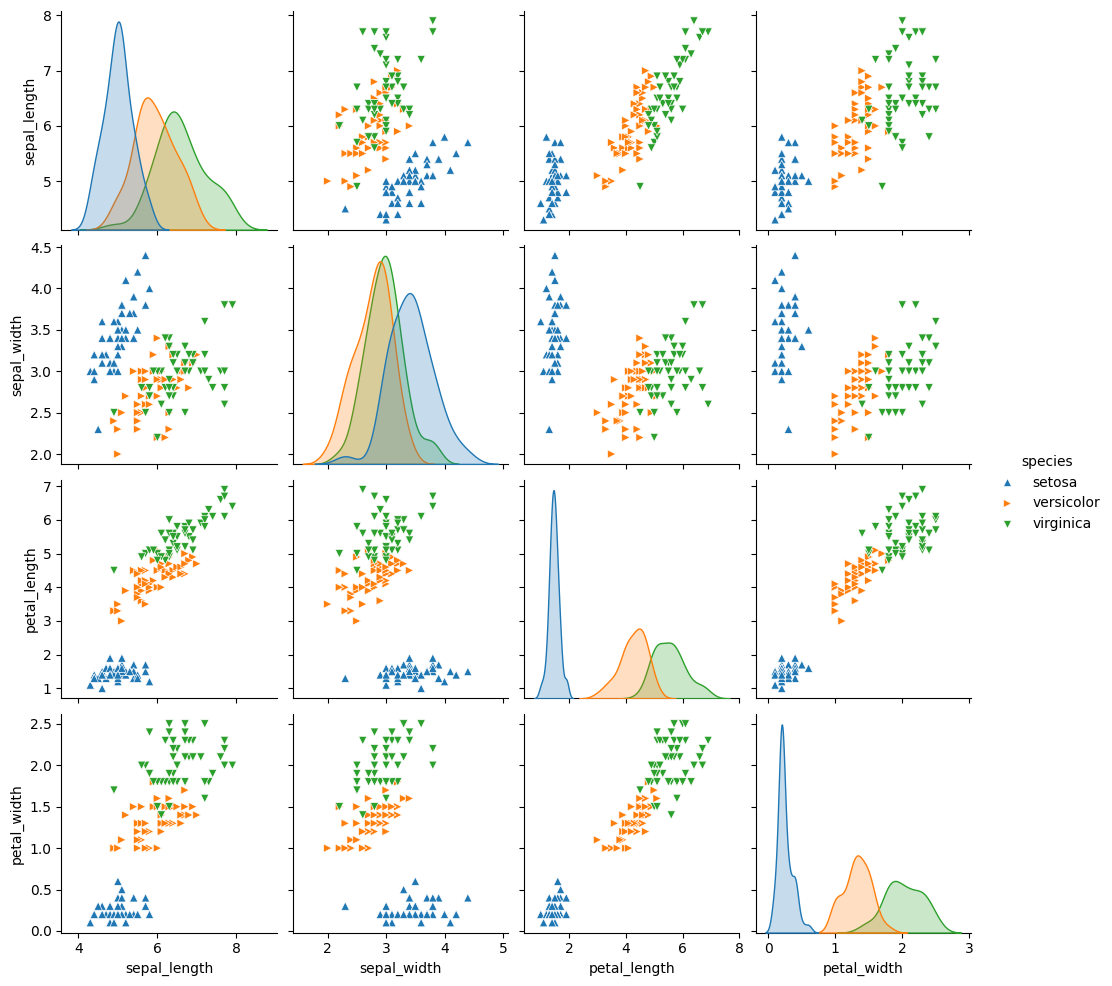

In [3]:
sns.pairplot(df, hue='species', markers=['^', '>', 'v'])
plt.show()

# 1. ülesanne

Järgmise koodilõigu abil mõelgem esmalt 2-mõõtmelise ning hiljem 4-mõõtmelise normaaljaotuse kovariatsioonimaatriksi elementide tähendusest. Võtame joonise liigi _Iris virginica_ andmetega ning genereerime joonisele juurde 50 punkti 4-mõõtmelisest normaaljaotusest, mille keskväärtus on samas kus _Iris virginica_ keskväärtus, aga kovariatsioonimaatriks on diagonaalne, väärtustega 1 diagonaalil.

Kuidas mõjutab erinevate kovariatsioonimaatriksi elementide muutmine joonist? Proovige leida kovariatsioonimaatriksi elementidele sellised väärtused, et genereeritud punktid hakkaksid omama sarnast jaotust nagu _Iris virginica_ punktid. Peale 5-10 minutit katsetamist leidke liigi _Iris virginica_ andmete tegelik kovariatsioonimaatriks.


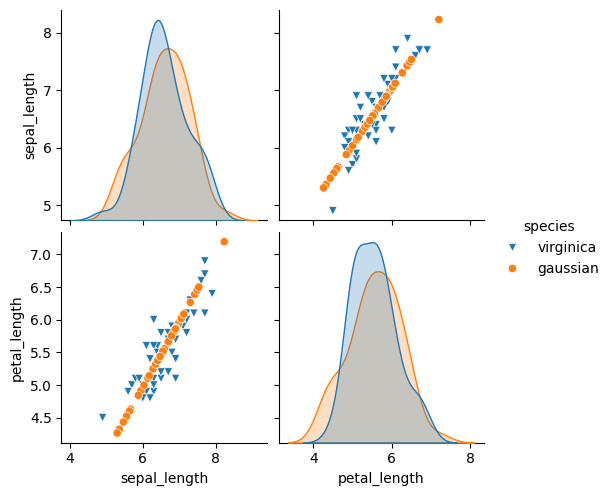

In [26]:
virginica_df = df[df.species == 'virginica'][
    ['sepal_length', 'petal_length', 'species']
]

mu = virginica_df[['sepal_length','petal_length']].mean()
cov = np.array([
    [0.5, 0.5],
    [0.5, 0.5]
])
rng = np.random.default_rng(0)

gaussian_df = pd.DataFrame(
    data = rng.multivariate_normal(mu, cov, size=50),
    columns = ['sepal_length','petal_length']
)
gaussian_df['species'] = 'gaussian'

sns.pairplot(
    data = pd.concat([virginica_df, gaussian_df]),
    hue = 'species', markers = ['v', 'o']
)
plt.show()

In [27]:
virginica_df = df[df.species == 'virginica'][
	['sepal_length', 'petal_length']
]

virginica_df.cov()


,sepal_length,petal_length
sepal_length,0.404343,0.303290
petal_length,0.303290,0.304588


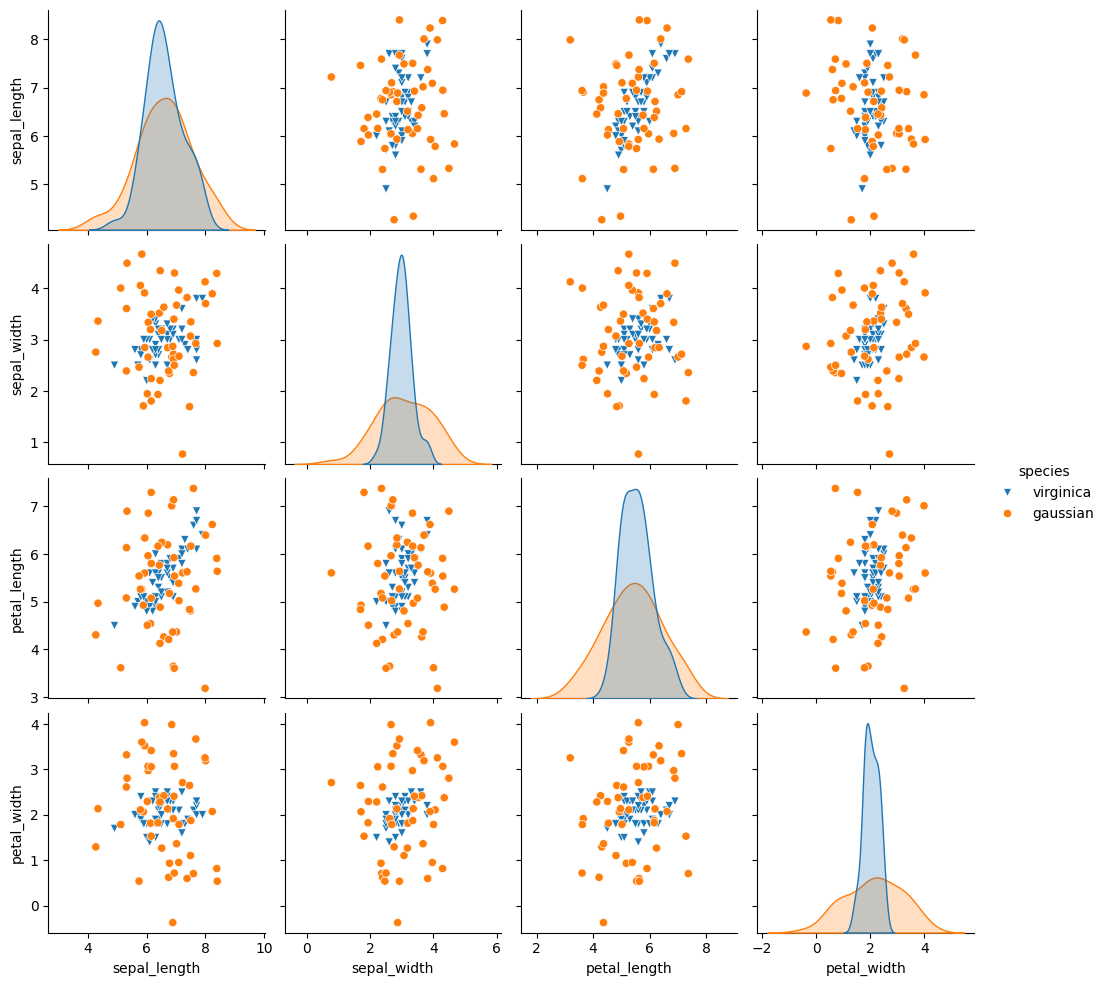

In [5]:
virginica_df = df[df.species == 'virginica']

mu = virginica_df.drop('species', axis=1).mean()

cov = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])
#cov = np.diag([0.4, 0.11, 0.3, 0.1])
rng = np.random.default_rng(0)

gen_df = pd.DataFrame(
    data = rng.multivariate_normal(mu, cov, size=50),
    columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)
gen_df['species'] = 'gaussian'

sns.pairplot(
    data = pd.concat([virginica_df, gen_df]),
    hue = 'species', markers = ['v','o']
)
plt.show()

In [ ]:
df[df.species == "virginica"].drop('species', axis=1).corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,0.457228,0.864225,0.281108
sepal_width,0.457228,1.000000,0.401045,0.537728
petal_length,0.864225,0.401045,1.000000,0.322108
petal_width,0.281108,0.537728,0.322108,1.000000


# 2. ülesanne

Rakendage K-keskmiste meetodit andmete klasterdamiseks. Katsetage parameetrite muutmisega. Jälgige tulemusi risttabelis ja joonisel.

1. Proovige muuta klastrite arvu. Jälgige, kuidas muutub seejuures risttabel.
2. Proovige muuta parameetrit max_iter. Mitu iteratsiooni on tüüpiliselt vaja, et mudel koonduks?
3. Proovige muuta juhuslikkuse seemet. Mis mõju on sel tulemustele?


In [34]:
dx = df.drop(columns = 'species')
km = KMeans(
    # proovida siin erinevaid
    n_clusters= 5, random_state = 0,
    n_init = "auto", max_iter = 300
).fit(dx)

print(f'WSS = {km.inertia_:.2f}') # Ruutkaugus oma klastri keskpunktist
clusters = km.predict(dx)
pd.crosstab(clusters, df.species)

WSS = 49.83


species,setosa,versicolor,virginica
row_0,,,
0,0,27,1
1,50,0,0
2,0,0,22
3,0,2,27
4,0,21,0


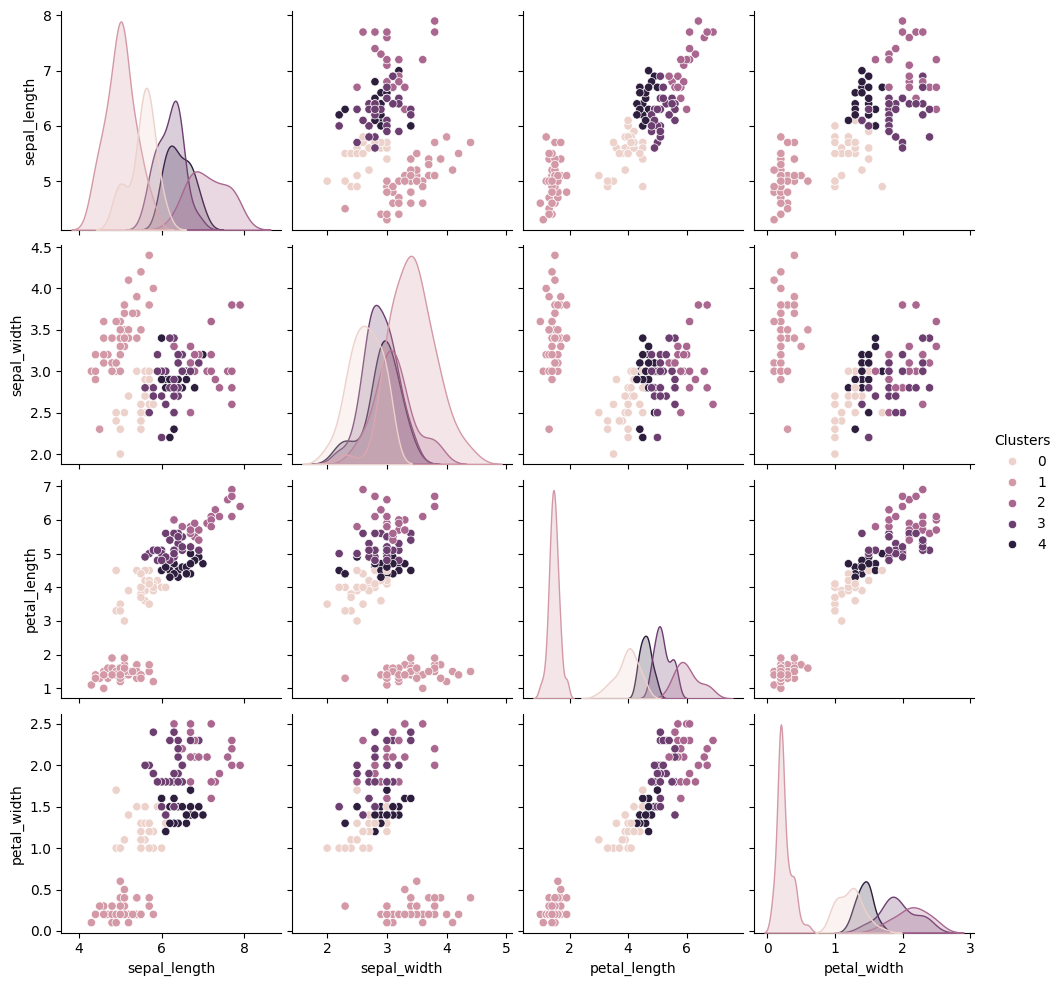

In [35]:
c = df.copy()
c['Clusters'] = clusters
sns.pairplot(c,hue='Clusters')
plt.show()

# 3. ülesanne


Rakendage küünarnukimeetodit K valimiseks K-keskmiste meetodis. Selleks lähtuge 2. ülesande koodist.


In [9]:
kmi = []
dx = df.drop(columns = 'species')

for i in range(1,21):
    km = KMeans(n_clusters = i, random_state = 0, n_init = "auto").fit(dx)
    print(f'WSS = {km.inertia_:.3f}')
    kmi.append(km.inertia_)

WSS = 681.371
WSS = 152.348
WSS = 78.856
WSS = 57.228
WSS = 49.828
WSS = 42.422
WSS = 34.420
WSS = 30.065
WSS = 28.716
WSS = 27.462
WSS = 25.479
WSS = 24.119
WSS = 23.030
WSS = 22.371
WSS = 20.329
WSS = 19.622
WSS = 18.908
WSS = 17.273
WSS = 16.694
WSS = 15.956


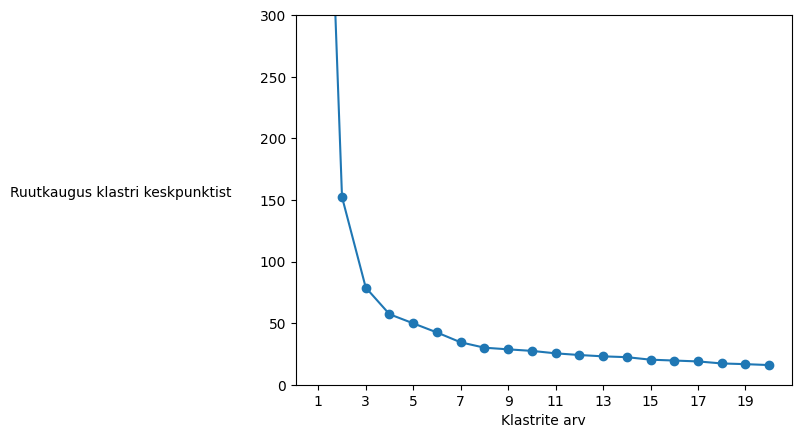

In [10]:
plt.plot(range(1,21), kmi, "-o")
plt.xticks(range(1,21, 2))
plt.ylim((0,300))
plt.xlabel("Klastrite arv")
plt.ylabel("Ruutkaugus klastri keskpunktist", rotation=0, labelpad=100)
plt.show()

# 4. ülesanne

Rakendame EM-algoritmi, et sobitada Gaussi segumudel. Seejärel genereerime sellest segumudelist andmed. Võrrelge genereeritud andmeid tegelike andmetega. Proovige erinevaid komponentide arve. Hinnake ristvalideerimisega NLL-i erinevate komponentide arvude korral ja leidke parim mudel.

### 1. Sobitame segumudeli


In [11]:
dx = df.drop(columns='species')

# Võrrelda erinevaid n_component väärtusi
gmm = GaussianMixture(n_components=3, random_state=0).fit(dx)

for i in range(gmm.n_components):
    print("----------------------------------")
    print(f"Komponendi {i} keskväärtuste vektor:")
    print(gmm.means_[i].round(3))
    print(f"\nKomponendi {i} kovariatsioonimaatriks:")
    print(gmm.covariances_[i].round(3))

----------------------------------
Komponendi 0 keskväärtuste vektor:
[5.917 2.778 4.205 1.298]

Komponendi 0 kovariatsioonimaatriks:
[[0.276 0.097 0.185 0.055]
 [0.097 0.093 0.091 0.043]
 [0.185 0.091 0.202 0.062]
 [0.055 0.043 0.062 0.032]]
----------------------------------
Komponendi 1 keskväärtuste vektor:
[5.006 3.428 1.462 0.246]

Komponendi 1 kovariatsioonimaatriks:
[[0.122 0.097 0.016 0.01 ]
 [0.097 0.141 0.011 0.009]
 [0.016 0.011 0.03  0.006]
 [0.01  0.009 0.006 0.011]]
----------------------------------
Komponendi 2 keskväärtuste vektor:
[6.546 2.949 5.484 1.987]

Komponendi 2 kovariatsioonimaatriks:
[[0.387 0.092 0.302 0.061]
 [0.092 0.11  0.084 0.056]
 [0.302 0.084 0.326 0.073]
 [0.061 0.056 0.073 0.085]]


### 2. Genereerime mudelist andmed ja visualiseerime


In [12]:
g = gmm.sample(150)
gen_df = pd.DataFrame(g[0], columns = dx.columns)
gen_df['species'] = g[1]
gen_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,6.052910,2.722039,4.165110,1.395266,0
1,5.584067,2.636838,3.809129,1.216251,0
2,5.152478,2.530455,3.571587,1.047630,0
3,7.327968,3.410059,5.109873,1.544008,0
4,4.551836,2.475444,3.384619,1.097028,0
...,...,...,...,...,...
145,6.576566,3.769218,5.504477,2.691575,2
146,6.639260,3.250676,5.493948,2.266452,2
147,6.673794,3.010913,5.892866,2.142661,2
148,7.406057,3.014302,6.469209,2.216439,2


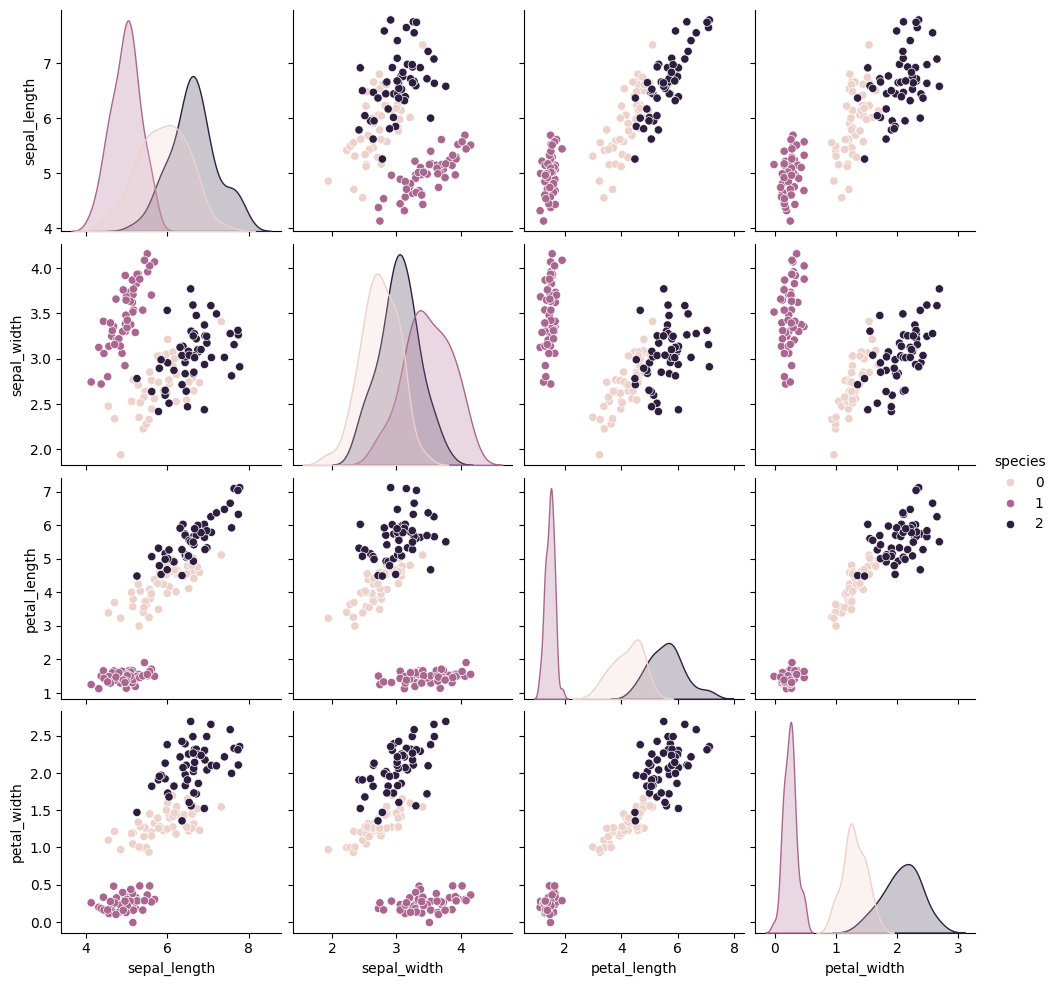

In [13]:
sns.pairplot(gen_df, hue='species')
plt.show()

### 3. Võrdleme genereeritud andmeid päris andmetega


In [14]:
koos = pd.concat([gen_df, df], ignore_index=True)
koos

,sepal_length,sepal_width,petal_length,petal_width,species
0,6.052910,2.722039,4.165110,1.395266,0
1,5.584067,2.636838,3.809129,1.216251,0
2,5.152478,2.530455,3.571587,1.047630,0
3,7.327968,3.410059,5.109873,1.544008,0
4,4.551836,2.475444,3.384619,1.097028,0
...,...,...,...,...,...
295,6.700000,3.000000,5.200000,2.300000,virginica
296,6.300000,2.500000,5.000000,1.900000,virginica
297,6.500000,3.000000,5.200000,2.000000,virginica
298,6.200000,3.400000,5.400000,2.300000,virginica


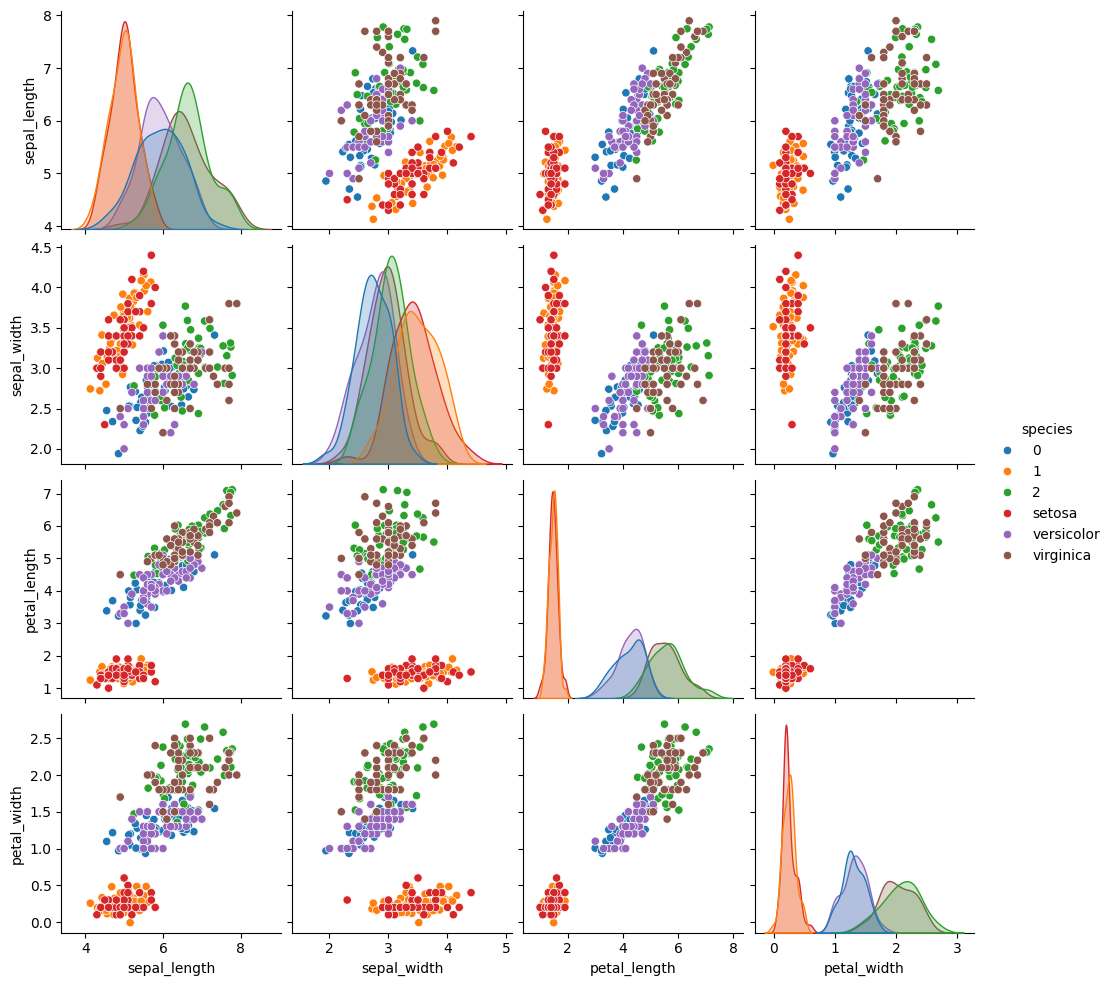

In [15]:
sns.pairplot(koos, hue='species')
plt.show()

### 4. Leiame parima segumudeli komponentide arvu ristvalideerimise abil


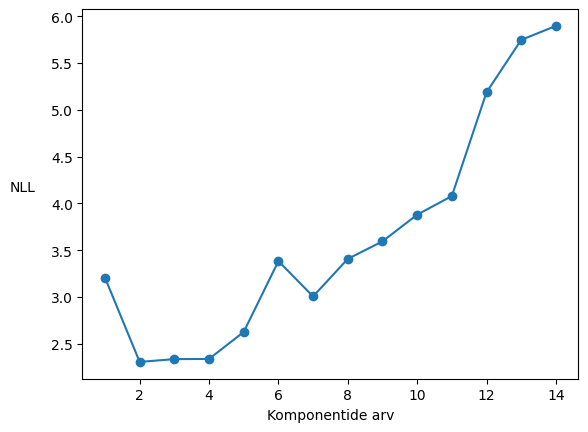

In [16]:
gmm = GaussianMixture(random_state=2)

cluster_sizes = range(1, 15)
param_grid = [
  {'n_components': cluster_sizes}
 ]
search = GridSearchCV(gmm, param_grid, cv=5).fit(dx)
nll = -search.cv_results_['mean_test_score']

plt.plot(cluster_sizes, nll, "-o")
plt.xlabel('Komponentide arv')
plt.ylabel('NLL', rotation=0, labelpad=20)
plt.show()